In [2]:
# ============================================================
# CLASSIFICATION IMPROVED V2
# Cell 1 - Imports & Configuration
# ============================================================

import os
import gc
import random
import warnings

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Main configuration
# ------------------------------------------------------------

IMG_SIZE = (299, 299)
IMG_HEIGHT = 299
IMG_WIDTH = 299

BATCH_SIZE = 8

NUM_CLASSES = 4

CLASS_NAMES = [
    "Melanoma",
    "Basal Cell Carcinoma",
    "Squamous Cell Carcinoma",
    "MCC"
]

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

WORK_DIR = "/kaggle/working/classification_improved_v2"

os.makedirs(WORK_DIR, exist_ok=True)

MODEL_DIR = os.path.join(WORK_DIR, "models")
AUG_DIR = os.path.join(WORK_DIR, "augmented")
DATA_DIR = os.path.join(WORK_DIR, "data")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(AUG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# ------------------------------------------------------------
# GPU check
# ------------------------------------------------------------

print("=" * 60)
print("CLASSIFICATION IMPROVED V2")
print("=" * 60)

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

print("GPU count:", len(gpus))

if gpus:
    print("GPU available:")
    for gpu in gpus:
        print(" ", gpu)
else:
    print("WARNING: GPU not detected.")

# ------------------------------------------------------------
# Memory cleanup
# ------------------------------------------------------------

gc.collect()

print("\nConfiguration")
print("-" * 60)
print("Image size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)
print("Classes    :", NUM_CLASSES)
print("Class names:", CLASS_NAMES)
print("Work dir   :", WORK_DIR)

CLASSIFICATION IMPROVED V2
TensorFlow version: 2.20.0
GPU count: 1
GPU available:
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

Configuration
------------------------------------------------------------
Image size : (299, 299)
Batch size : 8
Classes    : 4
Class names: ['Melanoma', 'Basal Cell Carcinoma', 'Squamous Cell Carcinoma', 'MCC']
Work dir   : /kaggle/working/classification_improved_v2


In [4]:
DERMACON_PATH = (
    "/kaggle/input/datasets/hiro002/dermacon-in-dataset"
)

# MCC datasets
MCC_DATASET_1 = (
    "/kaggle/input/datasets/quantumcoders05/mcc-3-dataset3"
)

MCC_DATASET_2 = (
    "/kaggle/input/datasets/quantumcoders05/mcc-dataset"
)

MCC_DATASET_3 = (
    "/kaggle/input/datasets/quantumcoders05/merkal-cell-carcinoma-04"
)

MCC_DATASET_4 = (
    "/kaggle/input/datasets/quantumcoders05/merkal-cell-carcinoma01"
)

# SCC dataset
SCC_DATASET = (
    "/kaggle/input/datasets/quantumcoders05/scc-dataset"
)

# ISIC 9-class dataset
ISIC_9CLASS = (
    "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic"
)

# HAM10000
HAM10000_PATH = (
    "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
)

# All ISIC data
ALL_ISIC_PATH = (
    "/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629"
)

DATASET_PATHS = {
    "DermaCon-IN": DERMACON_PATH,
    "MCC-3": MCC_DATASET_1,
    "MCC": MCC_DATASET_2,
    "MCC-04": MCC_DATASET_3,
    "MCC-01": MCC_DATASET_4,
    "SCC": SCC_DATASET,
    "ISIC-9": ISIC_9CLASS,
    "HAM10000": HAM10000_PATH,
    "All-ISIC": ALL_ISIC_PATH
}

print("=" * 70)
print("DATASET PATH CHECK")
print("=" * 70)

for name, path in DATASET_PATHS.items():

    exists = os.path.exists(path)

    print(
        f"{name:<15} : "
        f"{'✓ FOUND' if exists else '✗ NOT FOUND'}"
    )

    if not exists:
        print("   ", path)

DATASET PATH CHECK
DermaCon-IN     : ✓ FOUND
MCC-3           : ✓ FOUND
MCC             : ✓ FOUND
MCC-04          : ✓ FOUND
MCC-01          : ✓ FOUND
SCC             : ✓ FOUND
ISIC-9          : ✓ FOUND
HAM10000        : ✓ FOUND
All-ISIC        : ✓ FOUND


In [7]:
def inspect_dataset(name, path):

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    if not os.path.exists(path):
        print("NOT FOUND")
        return

    # Top-level items
    try:
        items = os.listdir(path)

        print("\nTop-level items:")

        for item in items[:30]:
            full_path = os.path.join(path, item)

            if os.path.isdir(full_path):
                print(f"  [DIR]  {item}")
            else:
                print(f"  [FILE] {item}")

    except Exception as e:
        print("Error:", e)


# Inspect all datasets

for name, path in DATASET_PATHS.items():
    inspect_dataset(name, path)


DermaCon-IN

Top-level items:
  [DIR]  METADATA
  [FILE] train_CBM_SC_MC_type2.py
  [FILE] Infer_Swin_MC.ipynb
  [DIR]  DATASET
  [DIR]  checkpoints
  [FILE] Infer_CBM_MC.ipynb
  [FILE] README.md
  [FILE] train_CBM_SC_MC_type1.py
  [FILE] train_cbm_mc.py
  [FILE] Metadata_schema.md
  [FILE] train_swin_mc.py

MCC-3

Top-level items:
  [DIR]  MCC-3

MCC

Top-level items:
  [DIR]  Merkel Cell Carcinoma in Skin of Color Patients A Case Series

MCC-04

Top-level items:
  [DIR]  New folder

MCC-01

Top-level items:
  [DIR]  MCC-2

SCC

Top-level items:
  [DIR]  SCC-1

ISIC-9

Top-level items:
  [DIR]  Skin cancer ISIC The International Skin Imaging Collaboration
  [DIR]  skin cancer isic the international skin imaging collaboration

HAM10000

Top-level items:
  [FILE] hmnist_8_8_RGB.csv
  [FILE] hmnist_28_28_RGB.csv
  [DIR]  HAM10000_images_part_1
  [DIR]  ham10000_images_part_1
  [FILE] hmnist_8_8_L.csv
  [DIR]  HAM10000_images_part_2
  [DIR]  ham10000_images_part_2
  [FILE] hmnist_28_28_L

In [8]:
print("=" * 80)
print("SEARCHING FOR METADATA / LABEL FILES")
print("=" * 80)

extensions = (
    ".csv",
    ".json",
    ".xlsx",
    ".xls",
    ".txt"
)

for name, path in DATASET_PATHS.items():

    print("\n" + "-" * 80)
    print(name)
    print("-" * 80)

    found = []

    for root, dirs, files in os.walk(path):

        for file in files:

            if file.lower().endswith(extensions):

                full_path = os.path.join(root, file)
                found.append(full_path)

    if found:

        for file_path in found[:30]:
            print(file_path)

        if len(found) > 30:
            print(
                f"... and {len(found) - 30} more files"
            )

    else:
        print("No metadata files found.")

SEARCHING FOR METADATA / LABEL FILES

--------------------------------------------------------------------------------
DermaCon-IN
--------------------------------------------------------------------------------
/kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/train_split.csv
/kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/test_split.csv
/kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/Skin_Metadata.csv

--------------------------------------------------------------------------------
MCC-3
--------------------------------------------------------------------------------
No metadata files found.

--------------------------------------------------------------------------------
MCC
--------------------------------------------------------------------------------
No metadata files found.

--------------------------------------------------------------------------------
MCC-04
--------------------------------------------------------------------------------
No 

In [9]:
HAM_METADATA = os.path.join(
    HAM10000_PATH,
    "HAM10000_metadata.csv"
)

ham_df = pd.read_csv(HAM_METADATA)

print("=" * 70)
print("HAM10000 METADATA")
print("=" * 70)

print("Shape:", ham_df.shape)

print("\nColumns:")
print(ham_df.columns.tolist())

print("\nDiagnosis distribution:")
print(ham_df["dx"].value_counts())

HAM_LABEL_MAP = {
    "mel": "Melanoma",
    "bcc": "Basal Cell Carcinoma"
}


# Select only our required classes

ham_selected = ham_df[
    ham_df["dx"].isin(HAM_LABEL_MAP.keys())
].copy()

ham_selected["class_name"] = ham_selected["dx"].map(
    HAM_LABEL_MAP
)

HAM_IMAGE_DIRS = [
    os.path.join(
        HAM10000_PATH,
        "HAM10000_images_part_1"
    ),
    os.path.join(
        HAM10000_PATH,
        "HAM10000_images_part_2"
    ),
    os.path.join(
        HAM10000_PATH,
        "ham10000_images_part_1"
    ),
    os.path.join(
        HAM10000_PATH,
        "ham10000_images_part_2"
    )
]


# Create image lookup

ham_image_lookup = {}

for image_dir in HAM_IMAGE_DIRS:

    if not os.path.exists(image_dir):
        continue

    for filename in os.listdir(image_dir):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            image_id = os.path.splitext(filename)[0]

            ham_image_lookup[image_id] = os.path.join(
                image_dir,
                filename
            )


# Add image paths

ham_selected["image_path"] = ham_selected[
    "image_id"
].map(ham_image_lookup)


# Keep valid images only

ham_selected = ham_selected[
    ham_selected["image_path"].notna()
].copy()


ham_selected["dataset"] = "HAM10000"

print("\n" + "=" * 70)
print("HAM10000 SELECTED DATA")
print("=" * 70)

print("Selected images:", len(ham_selected))

print("\nClass distribution:")

print(
    ham_selected["class_name"].value_counts()
)

print("\nMissing image paths:",
      ham_selected["image_path"].isna().sum())

display(
    ham_selected[
        [
            "image_id",
            "dx",
            "class_name",
            "dataset",
            "image_path"
        ]
    ].head()
)

HAM10000 METADATA
Shape: (10015, 7)

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Diagnosis distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

HAM10000 SELECTED DATA
Selected images: 1627

Class distribution:
class_name
Melanoma                1113
Basal Cell Carcinoma     514
Name: count, dtype: int64

Missing image paths: 0


,image_id,dx,class_name,dataset,image_path
1211,ISIC_0025964,mel,Melanoma,HAM10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1212,ISIC_0030623,mel,Melanoma,HAM10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1213,ISIC_0027190,mel,Melanoma,HAM10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1214,ISIC_0031023,mel,Melanoma,HAM10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1215,ISIC_0028086,mel,Melanoma,HAM10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...


In [10]:
print("=" * 70)
print("ISIC-9 - SCC EXTRACTION")
print("=" * 70)

scc_paths = []

for root, dirs, files in os.walk(ISIC_9CLASS):

    # We only want SCC folders
    folder_name = os.path.basename(root).lower()

    if folder_name == "squamous cell carcinoma":

        for file in files:

            if file.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):

                scc_paths.append(
                    os.path.join(root, file)
                )


# Remove duplicate paths
scc_paths = sorted(list(set(scc_paths)))


# Create dataframe

scc_isic_df = pd.DataFrame({
    "image_path": scc_paths
})

scc_isic_df["class_name"] = (
    "Squamous Cell Carcinoma"
)

scc_isic_df["dataset"] = "ISIC-9"

print("\nSCC images found:", len(scc_isic_df))

print("\nClass distribution:")

print(
    scc_isic_df["class_name"].value_counts()
)

print("\nSample paths:")

display(
    scc_isic_df.head()
)

ISIC-9 - SCC EXTRACTION

SCC images found: 394

Class distribution:
class_name
Squamous Cell Carcinoma    394
Name: count, dtype: int64

Sample paths:


,image_path,class_name,dataset
0,/kaggle/input/datasets/nodoubttome/skin-cancer...,Squamous Cell Carcinoma,ISIC-9
1,/kaggle/input/datasets/nodoubttome/skin-cancer...,Squamous Cell Carcinoma,ISIC-9
2,/kaggle/input/datasets/nodoubttome/skin-cancer...,Squamous Cell Carcinoma,ISIC-9
3,/kaggle/input/datasets/nodoubttome/skin-cancer...,Squamous Cell Carcinoma,ISIC-9
4,/kaggle/input/datasets/nodoubttome/skin-cancer...,Squamous Cell Carcinoma,ISIC-9


In [11]:
print("=" * 70)
print("MCC DATASET EXTRACTION")
print("=" * 70)

MCC_PATHS = {
    "MCC-3": MCC_DATASET_1,
    "MCC-Case-Series": MCC_DATASET_2,
    "MCC-04": MCC_DATASET_3,
    "MCC-01": MCC_DATASET_4,
}

mcc_rows = []

for dataset_name, dataset_path in MCC_PATHS.items():

    print(f"\nScanning: {dataset_name}")
    print(dataset_path)

    count_before = len(mcc_rows)

    for root, dirs, files in os.walk(dataset_path):

        for file in files:

            if file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp")
            ):

                full_path = os.path.join(root, file)

                mcc_rows.append({
                    "image_path": full_path,
                    "class_name": "MCC",
                    "dataset": dataset_name
                })

    count_after = len(mcc_rows)

    print(
        "Images found:",
        count_after - count_before
    )


# Create dataframe

mcc_df = pd.DataFrame(mcc_rows)


# Remove duplicate image paths

before_duplicates = len(mcc_df)

mcc_df = mcc_df.drop_duplicates(
    subset=["image_path"]
).reset_index(drop=True)

after_duplicates = len(mcc_df)

print("\n" + "=" * 70)
print("MCC SUMMARY")
print("=" * 70)

print(
    "Total images before duplicate removal:",
    before_duplicates
)

print(
    "Duplicate images removed:",
    before_duplicates - after_duplicates
)

print(
    "Final unique MCC images:",
    after_duplicates
)

print("\nDataset-wise distribution:")

print(
    mcc_df["dataset"].value_counts()
)

print("\nClass distribution:")

print(
    mcc_df["class_name"].value_counts()
)

print("\nSample images:")

display(mcc_df.head())

MCC DATASET EXTRACTION

Scanning: MCC-3
/kaggle/input/datasets/quantumcoders05/mcc-3-dataset3
Images found: 20

Scanning: MCC-Case-Series
/kaggle/input/datasets/quantumcoders05/mcc-dataset
Images found: 6

Scanning: MCC-04
/kaggle/input/datasets/quantumcoders05/merkal-cell-carcinoma-04
Images found: 12

Scanning: MCC-01
/kaggle/input/datasets/quantumcoders05/merkal-cell-carcinoma01
Images found: 10

MCC SUMMARY
Total images before duplicate removal: 48
Duplicate images removed: 0
Final unique MCC images: 48

Dataset-wise distribution:
dataset
MCC-3              20
MCC-04             12
MCC-01             10
MCC-Case-Series     6
Name: count, dtype: int64

Class distribution:
class_name
MCC    48
Name: count, dtype: int64

Sample images:


,image_path,class_name,dataset
0,/kaggle/input/datasets/quantumcoders05/mcc-3-d...,MCC,MCC-3
1,/kaggle/input/datasets/quantumcoders05/mcc-3-d...,MCC,MCC-3
2,/kaggle/input/datasets/quantumcoders05/mcc-3-d...,MCC,MCC-3
3,/kaggle/input/datasets/quantumcoders05/mcc-3-d...,MCC,MCC-3
4,/kaggle/input/datasets/quantumcoders05/mcc-3-d...,MCC,MCC-3


In [12]:
print("=" * 70)
print("SCC ADDITIONAL DATASET")
print("=" * 70)

scc_extra_rows = []

for root, dirs, files in os.walk(SCC_DATASET):

    for file in files:

        if file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):

            scc_extra_rows.append({
                "image_path": os.path.join(root, file),
                "class_name": "Squamous Cell Carcinoma",
                "dataset": "SCC-Additional"
            })


scc_extra_df = pd.DataFrame(scc_extra_rows)

# Remove duplicate paths within this dataset
scc_extra_df = scc_extra_df.drop_duplicates(
    subset=["image_path"]
).reset_index(drop=True)


print("\nAdditional SCC images:",
      len(scc_extra_df))

print("\nDistribution:")
print(
    scc_extra_df["class_name"].value_counts()
)

display(scc_extra_df.head())

SCC ADDITIONAL DATASET

Additional SCC images: 12

Distribution:
class_name
Squamous Cell Carcinoma    12
Name: count, dtype: int64


,image_path,class_name,dataset
0,/kaggle/input/datasets/quantumcoders05/scc-dat...,Squamous Cell Carcinoma,SCC-Additional
1,/kaggle/input/datasets/quantumcoders05/scc-dat...,Squamous Cell Carcinoma,SCC-Additional
2,/kaggle/input/datasets/quantumcoders05/scc-dat...,Squamous Cell Carcinoma,SCC-Additional
3,/kaggle/input/datasets/quantumcoders05/scc-dat...,Squamous Cell Carcinoma,SCC-Additional
4,/kaggle/input/datasets/quantumcoders05/scc-dat...,Squamous Cell Carcinoma,SCC-Additional


In [13]:
print("=" * 70)
print("DERMACON-IN METADATA")
print("=" * 70)

TRAIN_META = os.path.join(
    DERMACON_PATH,
    "METADATA",
    "train_split.csv"
)

TEST_META = os.path.join(
    DERMACON_PATH,
    "METADATA",
    "test_split.csv"
)

SKIN_META = os.path.join(
    DERMACON_PATH,
    "METADATA",
    "Skin_Metadata.csv"
)

dermacon_train = pd.read_csv(TRAIN_META)
dermacon_test = pd.read_csv(TEST_META)
dermacon_skin = pd.read_csv(SKIN_META)


print("\nTrain split:")
print("Shape:", dermacon_train.shape)
print("Columns:")
print(dermacon_train.columns.tolist())


print("\nTest split:")
print("Shape:", dermacon_test.shape)
print("Columns:")
print(dermacon_test.columns.tolist())


print("\nSkin Metadata:")
print("Shape:", dermacon_skin.shape)
print("Columns:")
print(dermacon_skin.columns.tolist())

print("\n" + "=" * 70)
print("TRAIN SAMPLE")
print("=" * 70)

display(dermacon_train.head())


print("\n" + "=" * 70)
print("SKIN METADATA SAMPLE")
print("=" * 70)

display(dermacon_skin.head())

DERMACON-IN METADATA

Train split:
Shape: (4399, 108)
Columns:
['Age', 'Body_part_Armpits (Axillary Region)', 'Body_part_Back', 'Body_part_Back of the Knees (Popliteal Region)', 'Body_part_Breasts (Mammary Region)', 'Body_part_Calves (Sural Region)', 'Body_part_Genital Area (Pubic Region)', 'Body_part_Groin (Inguinal Region)', 'Body_part_Head Cheeks', 'Body_part_Head Chin', 'Body_part_Head Ears', 'Body_part_Head Eye', 'Body_part_Head Forehead', 'Body_part_Head Lips', 'Body_part_Head Nose', 'Body_part_Head Scalp', 'Body_part_Head Temples', 'Body_part_Lower Extremities Ankles (Tarsal Region)', 'Body_part_Lower Extremities Feet (Pedal Region)', 'Body_part_Lower Extremities Feet (Pedal Region) Toes (Digits)', 'Body_part_Lower Extremities Hips (Coxal Region)', 'Body_part_Lower Extremities Knees (Patellar Region)', 'Body_part_Lower Extremities Lower Legs', 'Body_part_Lower Extremities Lower Legs (Crural Region)', 'Body_part_Lower Extremities Soles (Plantar Region)', 'Body_part_Lower Extremit

,Age,Body_part_Armpits (Axillary Region),Body_part_Back,Body_part_Back of the Knees (Popliteal Region),Body_part_Breasts (Mammary Region),Body_part_Calves (Sural Region),Body_part_Genital Area (Pubic Region),Body_part_Groin (Inguinal Region),Body_part_Head Cheeks,Body_part_Head Chin,...,Disease_label,Fitzpatrick,Gradability,Image_name,Main_class,Monk_skin_tone,Quality,Sex,Sub_class,Subject_ID
0,10 - 20,0,0,0,0,0,0,1,0,0,...,Steroid Modified Tinea,FST 3,Yes,IMG_0002.jpg,Infectious Disorders,MST 5,"Yes, the quality is sufficient for me or anoth...",Male,Infectious skin conditions -Fungal,SUB00001
1,10 - 20,0,0,0,0,0,0,1,0,0,...,Steroid Modified Tinea,FST 3,Yes,IMG_0005.jpg,Infectious Disorders,MST 5,"Yes, the quality is sufficient for me or anoth...",Male,Infectious skin conditions -Fungal,SUB00001
2,40 - 60,0,0,0,0,0,0,0,1,0,...,Acne,FST 4,Yes,IMG_0009.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002
3,40 - 60,0,0,0,0,0,0,0,1,0,...,Acne,FST 4,Yes,IMG_0010.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002
4,40 - 60,0,0,0,0,0,0,0,1,0,...,Acne,FST 4,Yes,IMG_0011.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002



SKIN METADATA SAMPLE


,Age,Body_part,Descriptors,Confidence,Disease_label,Fitzpatrick,Gradability,Image_name,Main_class,Monk_skin_tone,Quality,Sex,Sub_class,Subject_ID
0,10 - 20,"Groin (Inguinal Region),Lower Extremities Thig...","Erythema, Pigmented, Plaque",5,Steroid Modified Tinea,FST 3,Yes,IMG_0002.jpg,Infectious Disorders,MST 5,"Yes, the quality is sufficient for me or anoth...",Male,Infectious skin conditions -Fungal,SUB00001
1,10 - 20,"Groin (Inguinal Region),Lower Extremities Thig...","Erythema, Pigmented, Plaque",5,Steroid Modified Tinea,FST 3,Yes,IMG_0005.jpg,Infectious Disorders,MST 5,"Yes, the quality is sufficient for me or anoth...",Male,Infectious skin conditions -Fungal,SUB00001
2,40 - 60,Head Cheeks,Papule,5,Acne,FST 4,Yes,IMG_0009.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002
3,40 - 60,Head Cheeks,Papule,5,Acne,FST 4,Yes,IMG_0010.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002
4,40 - 60,"Head Cheeks,Head Nose,Head Lips",Papule,5,Acne,FST 4,Yes,IMG_0011.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002


In [1]:
import torch

print(torch.cuda.is_available())

True


In [2]:
import os

print(os.listdir("/kaggle/input/datasets/"))

['quantumcoders05', 'kmader', 'tomooinubushi', 'hiro002']


In [11]:
os.listdir("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000")

['hmnist_8_8_RGB.csv',
 'hmnist_28_28_RGB.csv',
 'HAM10000_images_part_1',
 'ham10000_images_part_1',
 'hmnist_8_8_L.csv',
 'HAM10000_images_part_2',
 'ham10000_images_part_2',
 'hmnist_28_28_L.csv',
 'HAM10000_metadata.csv']

In [12]:
os.listdir("/kaggle/input/datasets/hiro002/dermacon-in-dataset")

['METADATA',
 'train_CBM_SC_MC_type2.py',
 'Infer_Swin_MC.ipynb',
 'DATASET',
 'checkpoints',
 'Infer_CBM_MC.ipynb',
 'README.md',
 'train_CBM_SC_MC_type1.py',
 'train_cbm_mc.py',
 'Metadata_schema.md',
 'train_swin_mc.py']

In [3]:
os.listdir("/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629")

['image.hdf5',
 'image_256sq.hdf5',
 'licenses',
 'images',
 'attribution.txt',
 'metadata.csv']

In [10]:
import pandas as pd
import numpy as np
import os

In [11]:
ham_path="/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv"

ham=pd.read_csv(ham_path)

print(ham.head())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [12]:
for root,dirs,files in os.walk("/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root,file))

/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629/metadata.csv


In [13]:
isic=pd.read_csv(
"/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629/metadata.csv"
)

print(isic.head())

        isic_id                             attribution copyright_license  \
0  ISIC_7559201  Memorial Sloan Kettering Cancer Center             CC-BY   
1  ISIC_0485014  Memorial Sloan Kettering Cancer Center             CC-BY   
2  ISIC_5257439  Memorial Sloan Kettering Cancer Center             CC-BY   
3  ISIC_2989732  Memorial Sloan Kettering Cancer Center             CC-BY   
4  ISIC_5638210  Memorial Sloan Kettering Cancer Center             CC-BY   

   acquisition_day  age_approx anatom_site_general benign_malignant  \
0           2497.0        55.0      anterior torso           benign   
1              1.0        45.0     lower extremity           benign   
2           2360.0        40.0       lateral torso           benign   
3             78.0        80.0      anterior torso           benign   
4             78.0        80.0      anterior torso           benign   

   clin_size_long_diam_mm concomitant_biopsy       dermoscopic_type  ...  \
0                     6.6         

/tmp/ipykernel_58/4163445227.py:1: DtypeWarning: Columns (8,13,16,17,19) have mixed types. Specify dtype option on import or set low_memory=False.
  isic=pd.read_csv(


In [14]:
for root,dirs,files in os.walk("/kaggle/input/datasets/hiro002/dermacon-in-dataset"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root,file))

/kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/train_split.csv
/kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/test_split.csv
/kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/Skin_Metadata.csv


In [15]:
derma=pd.read_csv(
"/kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/Skin_Metadata.csv"
)
print(derma.head())

       Age                                          Body_part  \
0  10 - 20  Groin (Inguinal Region),Lower Extremities Thig...   
1  10 - 20  Groin (Inguinal Region),Lower Extremities Thig...   
2  40 - 60                                        Head Cheeks   
3  40 - 60                                        Head Cheeks   
4  40 - 60                    Head Cheeks,Head Nose,Head Lips   

                   Descriptors  Confidence           Disease_label  \
0  Erythema, Pigmented, Plaque           5  Steroid Modified Tinea   
1  Erythema, Pigmented, Plaque           5  Steroid Modified Tinea   
2                       Papule           5                    Acne   
3                       Papule           5                    Acne   
4                       Papule           5                    Acne   

  Fitzpatrick Gradability    Image_name                 Main_class  \
0       FST 3         Yes  IMG_0002.jpg       Infectious Disorders   
1       FST 3         Yes  IMG_0005.jpg       In

In [16]:
print("HAM")
print(ham.columns)

print("\nISIC")
print(isic.columns)

print("\nDERMA")
print(derma.columns)

HAM
Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')

ISIC
Index(['isic_id', 'attribution', 'copyright_license', 'acquisition_day',
       'age_approx', 'anatom_site_general', 'benign_malignant',
       'clin_size_long_diam_mm', 'concomitant_biopsy', 'dermoscopic_type',
       'diagnosis', 'diagnosis_confirm_type', 'family_hx_mm',
       'fitzpatrick_skin_type', 'image_type', 'lesion_id', 'mel_class',
       'mel_mitotic_index', 'mel_thick_mm', 'mel_type', 'mel_ulcer',
       'melanocytic', 'nevus_type', 'patient_id', 'personal_hx_mm', 'pixels_x',
       'pixels_y', 'sex'],
      dtype='object')

DERMA
Index(['Age', 'Body_part', 'Descriptors', 'Confidence', 'Disease_label',
       'Fitzpatrick', 'Gradability', 'Image_name', 'Main_class',
       'Monk_skin_tone', 'Quality', 'Sex', 'Sub_class', 'Subject_ID'],
      dtype='object')


In [34]:
ham_new=pd.DataFrame()

ham_new["image_name"]=ham["image_id"]

ham_new["class_name"]=ham["dx"]

ham_new["age"]=ham["age"]

ham_new["sex"]=ham["sex"]

ham_new["dataset"]="HAM10000"
ham_mapping = {
    "mel":0,
    "bcc":1,
    "scc":2
}

ham_new["label"] = ham_new["class_name"].map(ham_mapping)

ham_new = ham_new.dropna(subset=["label"])

In [37]:
isic_cancer = isic[
    isic["diagnosis"].str.contains(
        "melanoma|basal cell carcinoma|squamous cell carcinoma",
        case=False,
        na=False
    )
].copy()

In [39]:
isic_new=pd.DataFrame()

isic_new["image_name"]=isic["isic_id"]

isic_new["class_name"]=isic["diagnosis"]

isic_new["age"]=isic["age_approx"]

isic_new["sex"]=isic["sex"]

isic_new["dataset"]="isic2024"

In [40]:
isic_mapping = {

    "melanoma":0,

    "melanoma metastasis":0,

    "basal cell carcinoma":1,

    "squamous cell carcinoma":2

}

isic_new["label"] = (
    isic_new["class_name"]
    .str.lower()
    .map(isic_mapping)
)

isic_new = isic_new.dropna(subset=["label"])

In [ ]:
derma_cancer = derma[
    derma["Disease_label"].str.contains(
        "Melanoma|Basal Cell Carcinoma|Squamous Cell Carcinoma",
        case=False,
        na=False
    )
].copy()

In [42]:
derma_new=pd.DataFrame()

derma_new["image_name"]=derma["Image_name"]

derma_new["class_name"]=derma["Disease_label"]

derma_new["age"]=derma["Age"]

derma_new["sex"]=derma["Sex"]

derma_new["dataset"]="dermacon_in"

In [43]:
derma_mapping = {

    "Melanoma":0,

    "Basal Cell Carcinoma":1,

    "Squamous Cell Carcinoma":2

}

derma_new["label"] = derma_new["class_name"].map(derma_mapping)

derma_new = derma_new.dropna(subset=["label"])

In [44]:
print(ham_new.shape)

print(isic_new.shape)

print(derma_new.shape)

(1627, 6)
(13681, 6)
(17, 6)


In [46]:
combined = pd.concat(
    [ham_new, isic_new, derma_new],
    ignore_index=True
)

In [47]:
print(combined["dataset"].value_counts())

print(combined["label"].value_counts())

dataset
isic2024       13681
HAM10000        1627
dermacon_in       17
Name: count, dtype: int64
label
0.0    8503
1.0    5445
2.0    1377
Name: count, dtype: int64


In [48]:
# Dataset Shape
print("Dataset Shape:", combined.shape)

# Column Names
print("\nColumns:")
print(combined.columns.tolist())

# First Five Records
display(combined.head())

Dataset Shape: (15325, 6)

Columns:
['image_name', 'class_name', 'age', 'sex', 'dataset', 'label']


,image_name,class_name,age,sex,dataset,label
0,ISIC_0025964,mel,40.0,female,HAM10000,0.0
1,ISIC_0030623,mel,40.0,female,HAM10000,0.0
2,ISIC_0027190,mel,80.0,male,HAM10000,0.0
3,ISIC_0031023,mel,60.0,male,HAM10000,0.0
4,ISIC_0028086,mel,60.0,male,HAM10000,0.0


In [49]:
missing_values = combined.isnull().sum()

print("Missing Values:")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values:
image_name      0
class_name      0
age           359
sex           336
dataset         0
label           0
dtype: int64

Total Missing Values: 695


In [50]:
# Check duplicate metadata rows

duplicate_rows = combined.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_rows)

# Show duplicate rows (if any)
if duplicate_rows > 0:
    display(combined[combined.duplicated()].head())

Number of Duplicate Rows: 0


dataset
isic2024       13681
HAM10000        1627
dermacon_in       17
Name: count, dtype: int64


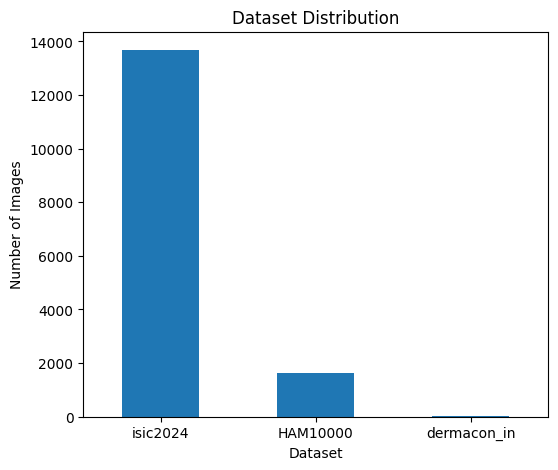

In [51]:
import matplotlib.pyplot as plt

# Count images from each dataset
dataset_counts = combined['dataset'].value_counts()

print(dataset_counts)

# Plot dataset distribution
plt.figure(figsize=(6,5))
dataset_counts.plot(kind='bar')

plt.title("Dataset Distribution")
plt.xlabel("Dataset")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.show()

In [53]:
combined["dataset"] = combined["dataset"].replace({
    "isic2024": "ISIC 2024",
    "HAM10000": "HAM10000",
    "dermacon_in": "DermaCon-IN"
})

Cancer Class Distribution:
class_name
melanoma                   7349
basal cell carcinoma       4921
squamous cell carcinoma    1372
mel                        1113
bcc                         514
melanoma metastasis          39
Basal Cell Carcinoma         10
Squamous Cell Carcinoma       5
Melanoma                      2
Name: count, dtype: int64


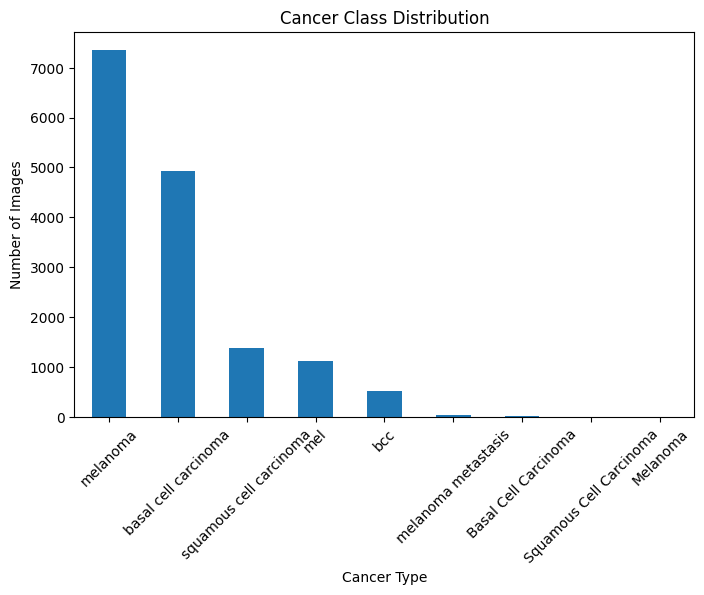

In [54]:
import matplotlib.pyplot as plt

# Count images in each cancer class
class_counts = combined["class_name"].value_counts()

print("Cancer Class Distribution:")
print(class_counts)

# Plot
plt.figure(figsize=(8,5))
class_counts.plot(kind="bar")

plt.title("Cancer Class Distribution")
plt.xlabel("Cancer Type")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.show()

In [56]:
# Standardize cancer class names

combined["class_name"] = combined["class_name"].replace({
    "mel": "Melanoma",
    "melanoma": "Melanoma",
    "Melanoma": "Melanoma",

    "bcc": "Basal Cell Carcinoma",
    "basal cell carcinoma": "Basal Cell Carcinoma",
    "Basal Cell Carcinoma": "Basal Cell Carcinoma",

    "squamous cell carcinoma": "Squamous Cell Carcinoma",
    "Squamous Cell Carcinoma": "Squamous Cell Carcinoma",

    "mcc": "Merkel Cell Carcinoma",
    "merkel cell carcinoma": "Merkel Cell Carcinoma",
    "Merkel Cell Carcinoma": "Merkel Cell Carcinoma"
})

In [57]:
class_counts = combined["class_name"].value_counts()

print(class_counts)

class_name
Melanoma                   8464
Basal Cell Carcinoma       5445
Squamous Cell Carcinoma    1377
melanoma metastasis          39
Name: count, dtype: int64


In [58]:
combined["class_name"] = combined["class_name"].replace({
    "melanoma metastasis": "Melanoma"
})

In [59]:
# Merge metastatic melanoma into Melanoma

combined["class_name"] = combined["class_name"].replace({
    "melanoma metastasis": "Melanoma"
})

# Check final class distribution
class_counts = combined["class_name"].value_counts()

print(class_counts)

class_name
Melanoma                   8503
Basal Cell Carcinoma       5445
Squamous Cell Carcinoma    1377
Name: count, dtype: int64


In [60]:
import os

# Check Kaggle working directory
print("Files and folders in /kaggle/working:")

for item in os.listdir("/kaggle/working"):
    print(item)

Files and folders in /kaggle/working:
.virtual_documents


In [61]:
mcc_path = "/kaggle/input/datasets/quantumcoders05/mcc-dataset"  

for root, dirs, files in os.walk(mcc_path):
    print("\nFolder:", root)
    print("Number of files:", len(files))
    print("Sample files:", files[:5])


Folder: /kaggle/input/datasets/quantumcoders05/mcc-dataset
Number of files: 0
Sample files: []

Folder: /kaggle/input/datasets/quantumcoders05/mcc-dataset/Merkel Cell Carcinoma in Skin of Color Patients A Case Series
Number of files: 6
Sample files: ['Supplemental Figure 1b (2).jpg', 'Supplemental Figure 1b.jpg', 'Supplemental Figure 2b.jpg', 'Supplemental Figure 2a.png', 'Supplemental Figure 2b (2).jpg']


In [62]:
from PIL import Image
import os

mcc_path = "/kaggle/input/datasets/quantumcoders05/mcc-dataset/Merkel Cell Carcinoma in Skin of Color Patients A Case Series"

mcc_files = [
    os.path.join(mcc_path, f)
    for f in os.listdir(mcc_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of MCC image files:", len(mcc_files))

for path in mcc_files:
    try:
        img = Image.open(path)
        print(os.path.basename(path), "→", img.size, "→", img.mode)
    except Exception as e:
        print("Error:", os.path.basename(path), e)

Number of MCC image files: 6
Supplemental Figure 1b (2).jpg → (922, 656) → RGB
Supplemental Figure 1b.jpg → (922, 660) → RGB
Supplemental Figure 2b.jpg → (633, 452) → RGB
Supplemental Figure 2a.png → (840, 754) → RGBA
Supplemental Figure 2b (2).jpg → (596, 452) → RGB
Supplemental Figure 1a.jpg → (880, 778) → RGB


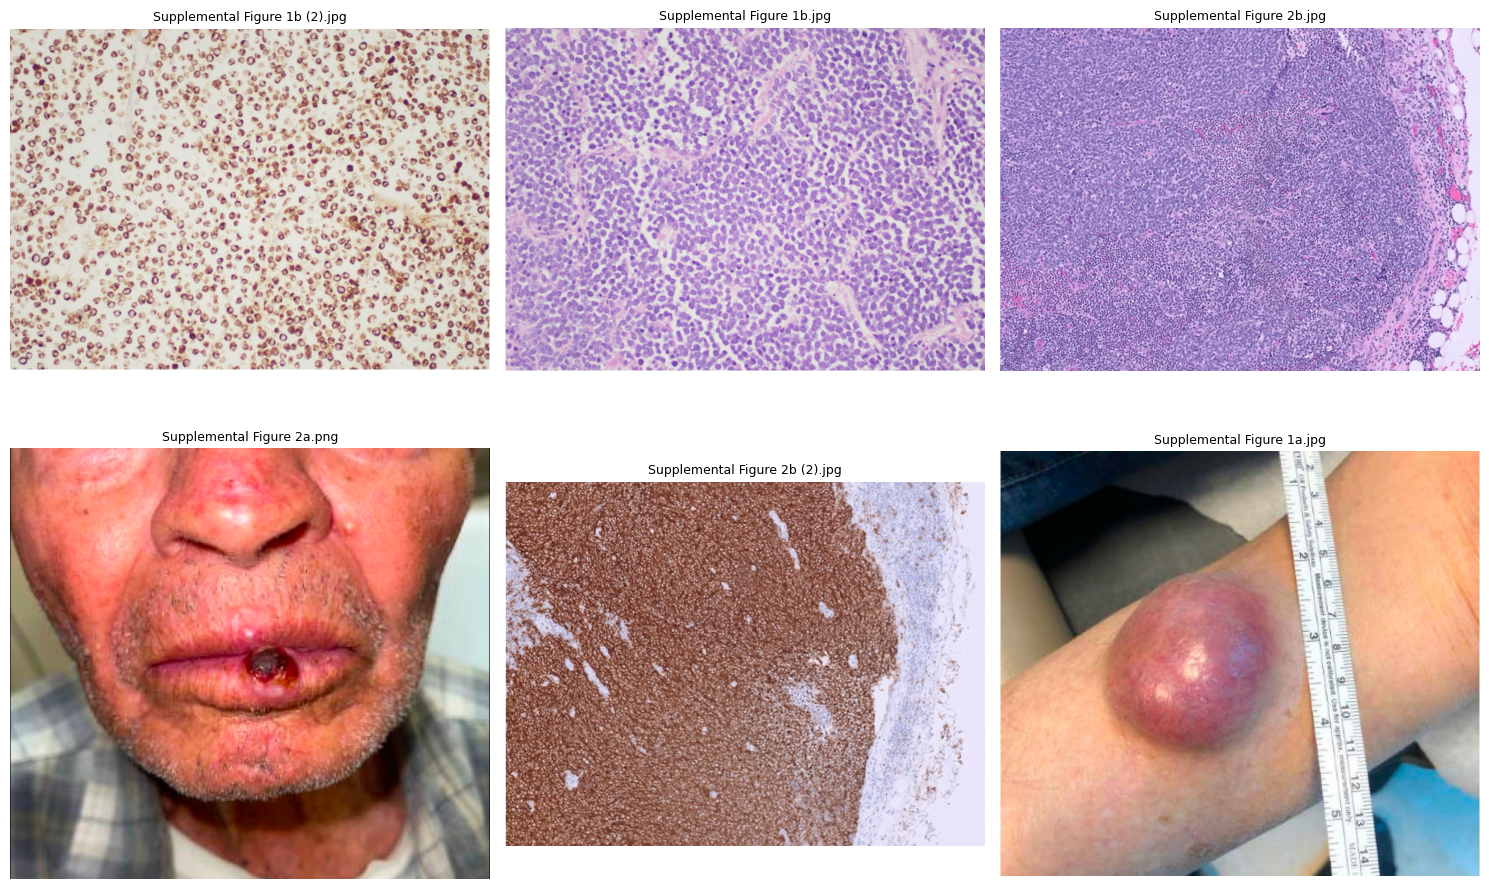

In [63]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, path in zip(axes.ravel(), mcc_files):
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.set_title(os.path.basename(path), fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [64]:
mcc_df = pd.DataFrame({
    "image_name": [os.path.basename(path) for path in mcc_files],
    "class_name": ["MCC"] * len(mcc_files),
    "dataset": ["MCC"] * len(mcc_files),
    "image_path": mcc_files
})

mcc_df.head()

,image_name,class_name,dataset,image_path
0,Supplemental Figure 1b (2).jpg,MCC,MCC,/kaggle/input/datasets/quantumcoders05/mcc-dat...
1,Supplemental Figure 1b.jpg,MCC,MCC,/kaggle/input/datasets/quantumcoders05/mcc-dat...
2,Supplemental Figure 2b.jpg,MCC,MCC,/kaggle/input/datasets/quantumcoders05/mcc-dat...
3,Supplemental Figure 2a.png,MCC,MCC,/kaggle/input/datasets/quantumcoders05/mcc-dat...
4,Supplemental Figure 2b (2).jpg,MCC,MCC,/kaggle/input/datasets/quantumcoders05/mcc-dat...


In [66]:
import pandas as pd
import os

mcc_df = pd.DataFrame({
    "image_name": [os.path.basename(path) for path in mcc_files],
    "class_name": ["MCC"] * len(mcc_files),
    "age": [None] * len(mcc_files),
    "sex": [None] * len(mcc_files),
    "dataset": ["MCC"] * len(mcc_files),
    "label": [3] * len(mcc_files),
    "image_path": mcc_files
})

print("MCC Dataset Shape:", mcc_df.shape)
display(mcc_df.head())

MCC Dataset Shape: (6, 7)


,image_name,class_name,age,sex,dataset,label,image_path
0,Supplemental Figure 1b (2).jpg,MCC,None,None,MCC,3,/kaggle/input/datasets/quantumcoders05/mcc-dat...
1,Supplemental Figure 1b.jpg,MCC,None,None,MCC,3,/kaggle/input/datasets/quantumcoders05/mcc-dat...
2,Supplemental Figure 2b.jpg,MCC,None,None,MCC,3,/kaggle/input/datasets/quantumcoders05/mcc-dat...
3,Supplemental Figure 2a.png,MCC,None,None,MCC,3,/kaggle/input/datasets/quantumcoders05/mcc-dat...
4,Supplemental Figure 2b (2).jpg,MCC,None,None,MCC,3,/kaggle/input/datasets/quantumcoders05/mcc-dat...


In [67]:
combined["image_path"] = None

In [68]:
print(combined.columns)

Index(['image_name', 'class_name', 'age', 'sex', 'dataset', 'label',
       'image_path'],
      dtype='object')


In [69]:
combined = pd.concat(
    [combined, mcc_df],
    ignore_index=True
)

print("Updated Dataset Shape:", combined.shape)

Updated Dataset Shape: (15331, 7)


In [70]:
print("Final Class Distribution:")
print(combined["class_name"].value_counts())

Final Class Distribution:
class_name
Melanoma                   8503
Basal Cell Carcinoma       5445
Squamous Cell Carcinoma    1377
MCC                           6
Name: count, dtype: int64


In [71]:
import os

combined["image_exists"] = combined["image_path"].apply(
    lambda x: os.path.exists(x) if pd.notna(x) else False
)

print(combined["image_exists"].value_counts())

image_exists
False    15325
True         6
Name: count, dtype: int64


In [72]:
print(
    combined.groupby("dataset")["image_exists"]
    .value_counts()
)

dataset      image_exists
DermaCon-IN  False              17
HAM10000     False            1627
ISIC 2024    False           13681
MCC          True                6
Name: count, dtype: int64


In [73]:
from PIL import Image
import os

mcc_path = "/kaggle/input/datasets/quantumcoders05/mcc-dataset/Merkel Cell Carcinoma in Skin of Color Patients A Case Series"

# Only the 2 required images
required_images = [
    "Supplemental Figure 2a.png",
    "Supplemental Figure 1a.jpg"
]

for filename in required_images:
    path = os.path.join(mcc_path, filename)

    try:
        img = Image.open(path)
        print(filename, "→", img.size, "→", img.mode)
    except Exception as e:
        print("Error:", filename, e)

Supplemental Figure 2a.png → (840, 754) → RGBA
Supplemental Figure 1a.jpg → (880, 778) → RGB


In [74]:
# Select only the 2 required MCC images

selected_mcc_files = [
    "Supplemental Figure 2a.png",
    "Supplemental Figure 1a.jpg"
]

# Create full paths
selected_mcc_paths = [
    os.path.join(mcc_path, filename)
    for filename in selected_mcc_files
]

# Remove all existing MCC records
combined = combined[combined["class_name"] != "MCC"].copy()

# Create new MCC records
mcc_selected = pd.DataFrame({
    "image_path": selected_mcc_paths,
    "class_name": ["MCC", "MCC"],
    "dataset": ["MCC", "MCC"]
})

# Add selected MCC images
combined = pd.concat([combined, mcc_selected], ignore_index=True)

print("Updated Class Distribution:")
print(combined["class_name"].value_counts())

Updated Class Distribution:
class_name
Melanoma                   8503
Basal Cell Carcinoma       5445
Squamous Cell Carcinoma    1377
MCC                           2
Name: count, dtype: int64


In [75]:
print(combined[combined["class_name"] == "MCC"][["image_path", "class_name"]])

                                              image_path class_name
15325  /kaggle/input/datasets/quantumcoders05/mcc-dat...        MCC
15326  /kaggle/input/datasets/quantumcoders05/mcc-dat...        MCC


In [76]:
import os

combined["image_exists"] = combined["image_path"].apply(
    lambda x: os.path.exists(x) if pd.notna(x) else False
)

print(combined.groupby("class_name")["image_exists"].value_counts())

class_name               image_exists
Basal Cell Carcinoma     False           5445
MCC                      True               2
Melanoma                 False           8503
Squamous Cell Carcinoma  False           1377
Name: count, dtype: int64


In [77]:
print(combined.columns.tolist())

['image_name', 'class_name', 'age', 'sex', 'dataset', 'label', 'image_path', 'image_exists']


In [79]:
print(combined.head())

     image_name class_name   age     sex   dataset  label image_path  \
0  ISIC_0025964   Melanoma  40.0  female  HAM10000    0.0       None   
1  ISIC_0030623   Melanoma  40.0  female  HAM10000    0.0       None   
2  ISIC_0027190   Melanoma  80.0    male  HAM10000    0.0       None   
3  ISIC_0031023   Melanoma  60.0    male  HAM10000    0.0       None   
4  ISIC_0028086   Melanoma  60.0    male  HAM10000    0.0       None   

   image_exists  
0         False  
1         False  
2         False  
3         False  
4         False  


In [80]:
import os

base_path = "/kaggle/input"

for root, dirs, files in os.walk(base_path):
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    
    if image_files:
        print("Folder:", root)
        print("Number of images:", len(image_files))
        print("Sample:", image_files[:5])
        print("-" * 60)

Folder: /kaggle/input/datasets/quantumcoders05/mcc-dataset/Merkel Cell Carcinoma in Skin of Color Patients A Case Series
Number of images: 6
Sample: ['Supplemental Figure 1b (2).jpg', 'Supplemental Figure 1b.jpg', 'Supplemental Figure 2b.jpg', 'Supplemental Figure 2a.png', 'Supplemental Figure 2b (2).jpg']
------------------------------------------------------------
Folder: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1
Number of images: 5000
Sample: ['ISIC_0028933.jpg', 'ISIC_0028394.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']
------------------------------------------------------------
Folder: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_1
Number of images: 5000
Sample: ['ISIC_0028933.jpg', 'ISIC_0028394.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']
------------------------------------------------------------
Folder: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM1

In [81]:
import os

HAM1 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1"
HAM2 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2"

ISIC = "/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629/images"

DERMA0 = "/kaggle/input/datasets/hiro002/dermacon-in-dataset/DATASET/DATASET_0/DATASET_0"

DERMA1 = "/kaggle/input/datasets/hiro002/dermacon-in-dataset/DATASET/DATASET_1/DATASET_1"

MCC = "/kaggle/input/datasets/quantumcoders05/mcc-dataset/Merkel Cell Carcinoma in Skin of Color Patients A Case Series"

In [92]:
import os

def get_image_path(row):

    image = row["image_name"]

    # HAM10000
    if row["dataset"] == "HAM10000":

        p1 = os.path.join(HAM1, image + ".jpg")
        p2 = os.path.join(HAM2, image + ".jpg")

        if os.path.exists(p1):
            return p1
        elif os.path.exists(p2):
            return p2

    # ISIC 2024
    elif row["dataset"] == "ISIC 2024":

        return os.path.join(ISIC, image + ".jpg")

    # DermaCon-IN
    elif row["dataset"] == "DermaCon-IN":

        p0 = os.path.join(DERMA0, image)
        p1 = os.path.join(DERMA1, image)

        if os.path.exists(p0):
            return p0
        elif os.path.exists(p1):
            return p1

    # MCC
    elif row["dataset"] == "MCC":

        return None

    return None

In [93]:
combined["image_path"] = combined.apply(get_image_path, axis=1)

In [94]:
print(combined["image_path"].isnull().sum())

2


In [95]:
combined["exists"] = combined["image_path"].apply(
    lambda x: os.path.exists(x) if pd.notnull(x) else False
)

combined["exists"].value_counts()

exists
True     15325
False        2
Name: count, dtype: int64

In [96]:
from PIL import Image

IMG_SIZE = (224,224)

sample = Image.open(combined.iloc[0]["image_path"])

print("Original Size :", sample.size)

sample = sample.resize(IMG_SIZE)

print("Resized Size :", sample.size)

Original Size : (600, 450)
Resized Size : (224, 224)


In [97]:
sample = sample.convert("RGB")

print(sample.mode)

RGB


In [98]:
import numpy as np

img = np.array(sample)/255.0

print(img.min())
print(img.max())

0.050980392156862744
0.9176470588235294


In [99]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    combined,
    test_size=0.30,
    stratify=combined["class_name"],
    random_state=42
)

# Second split: Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class_name"],
    random_state=42
)

print("Training :", len(train_df))
print("Validation :", len(val_df))
print("Testing :", len(test_df))

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.